# Laboratorio 2

## Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Para el desarrollo de esta actividad puedes utilizar cualquier librería externa. Te recomendamos leer por completo el enunciado del laboratorio antes de comenzar, de forma que tengas claro el propósito global de la actividad y puedas desarrollar tu solución apuntando a él desde el inicio.

Al desarrollar este laboratorio pondrás a prueba tus habilidades para:

1. Identificar y abordar preguntas de negocio y de *analytics*.
2. Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
3. Explorar, modificar, limpiar y unir objetos tablas de datos.
4. Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
5. Implementar análisis basado en modelos estadísticos o de *machine learning*.

##  Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia

El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11. 

Los objetivos de este caso de estudio son:

* Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.


* Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.


* Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el *stakeholder*.


* Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

## Fase 1: obtener e inspeccionar archivos

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

* Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos `append` o `concat` si eliges cargarlos utilizando la librería `pandas`).
* Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
* Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.

Preguntas guía:

* ¿Qué dimensiones tienen los datos?
* ¿Con cuántos años y periodos de evaluación se cuenta?
* ¿Cuáles variables pueden ser de interés para la problemática planteada?
* ¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

In [25]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [26]:

data1=pd.read_csv("Saber_11°_2020-1_20250928.csv")
data2=pd.read_csv("Saber_11°_2020-2_20250928.csv")

df = pd.concat([data1, data2], ignore_index=True)

print("Dimensiones:", df.shape)
df.info()
df.isnull().mean().sort_values(ascending=False).head(20)


Dimensiones: (520307, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520307 entries, 0 to 520306
Data columns (total 81 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ESTU_TIPODOCUMENTO             520307 non-null  object 
 1   ESTU_NACIONALIDAD              520307 non-null  object 
 2   ESTU_GENERO                    520298 non-null  object 
 3   ESTU_FECHANACIMIENTO           520307 non-null  object 
 4   PERIODO                        520307 non-null  object 
 5   ESTU_CONSECUTIVO               520307 non-null  object 
 6   ESTU_ESTUDIANTE                520307 non-null  object 
 7   ESTU_PAIS_RESIDE               520307 non-null  object 
 8   ESTU_TIENEETNIA                516550 non-null  object 
 9   ESTU_DEPTO_RESIDE              519541 non-null  object 
 10  ESTU_COD_RESIDE_DEPTO          519541 non-null  float64
 11  ESTU_MCPIO_RESIDE              519541 non-null  object 
 12  ESTU

COLE_BILINGUE                    0.164561
ESTU_NSE_INDIVIDUAL              0.056467
ESTU_INSE_INDIVIDUAL             0.056467
FAMI_COMECEREALFRUTOSLEGUMBRE    0.041919
FAMI_TIENECOMPUTADOR             0.041545
FAMI_TRABAJOLABORPADRE           0.040643
FAMI_TIENEAUTOMOVIL              0.037024
ESTU_TIPOREMUNERACION            0.036717
FAMI_TRABAJOLABORMADRE           0.036630
FAMI_TIENECONSOLAVIDEOJUEGOS     0.036380
FAMI_TIENEHORNOMICROOGAS         0.035708
FAMI_TIENEMOTOCICLETA            0.035627
FAMI_ESTRATOVIVIENDA             0.035575
ESTU_HORASSEMANATRABAJA          0.035371
FAMI_SITUACIONECONOMICA          0.034141
FAMI_TIENELAVADORA               0.033940
FAMI_CUARTOSHOGAR                0.033207
FAMI_TIENESERVICIOTV             0.032640
FAMI_COMECARNEPESCADOHUEVO       0.032367
FAMI_PERSONASHOGAR               0.031866
dtype: float64

In [27]:

variables_seleccionadas = [
    "ESTU_INSE_INDIVIDUAL",
    "FAMI_EDUCACIONPADRE",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "COLE_COD_DANE_SEDE",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_TIENEETNIA",
    "FAMI_NUMLIBROS",
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "ESTU_FECHANACIMIENTO",
    "PUNT_GLOBAL"

    
]


df_reducido = df[variables_seleccionadas].copy()

print("Dimensiones:", df_reducido.shape)
print(df_reducido.head())


Dimensiones: (520307, 15)
   ESTU_INSE_INDIVIDUAL                   FAMI_EDUCACIONPADRE  \
0                   NaN                   Primaria incompleta   
1                   NaN                                   NaN   
2                   NaN  Secundaria (Bachillerato) incompleta   
3                   NaN        Técnica o tecnológica completa   
4                   NaN        Educación profesional completa   

                    FAMI_EDUCACIONMADRE FAMI_TIENEINTERNET  \
0                   Primaria incompleta                 No   
1                                   NaN                NaN   
2  Secundaria (Bachillerato) incompleta                 No   
3        Educación profesional completa                 Si   
4    Secundaria (Bachillerato) completa                 Si   

  FAMI_TIENECOMPUTADOR COLE_COD_DANE_SEDE COLE_AREA_UBICACION COLE_JORNADA  \
0                   No    120,750,000,415              URBANO        NOCHE   
1                  NaN    352,356,001,951             

In [28]:

print("Tipos de datos en el DataFrame:")
print(df_reducido.dtypes)


for col in df_reducido.columns:
    if df_reducido[col].dtype == "object" or df_reducido[col].dtype == "string":
        print(f"\n--- {col} ---")
        print(df_reducido[col].unique())

Tipos de datos en el DataFrame:
ESTU_INSE_INDIVIDUAL    float64
FAMI_EDUCACIONPADRE      object
FAMI_EDUCACIONMADRE      object
FAMI_TIENEINTERNET       object
FAMI_TIENECOMPUTADOR     object
COLE_COD_DANE_SEDE       object
COLE_AREA_UBICACION      object
COLE_JORNADA             object
ESTU_NSE_INDIVIDUAL     float64
ESTU_TIENEETNIA          object
FAMI_NUMLIBROS           object
COLE_BILINGUE            object
COLE_CALENDARIO          object
ESTU_FECHANACIMIENTO     object
PUNT_GLOBAL               int64
dtype: object

--- FAMI_EDUCACIONPADRE ---
['Primaria incompleta' nan 'Secundaria (Bachillerato) incompleta'
 'Técnica o tecnológica completa' 'Educación profesional completa'
 'Primaria completa' 'Ninguno' 'Postgrado'
 'Secundaria (Bachillerato) completa' 'Educación profesional incompleta'
 'No sabe' 'No Aplica' 'Técnica o tecnológica incompleta']

--- FAMI_EDUCACIONMADRE ---
['Primaria incompleta' nan 'Secundaria (Bachillerato) incompleta'
 'Educación profesional completa' 'Secunda

In [29]:

df_encoded = df_reducido.copy()


map_educ_padre = {
    "Ninguno": 0,
    "No sabe": 1,
    "No Aplica": 2,
    "Primaria incompleta": 3,
    "Primaria completa": 4,
    "Secundaria (Bachillerato) incompleta": 5,
    "Secundaria (Bachillerato) completa": 6,
    "Técnica o tecnológica incompleta": 7,
    "Técnica o tecnológica completa": 8,
    "Educación profesional incompleta": 9,
    "Educación profesional completa": 10,
    "Postgrado": 11
}

map_educ_madre = map_educ_padre.copy()

map_si_no = {"No": 0, "Si": 1}
map_genero = {"F": 0, "M": 1}
map_bilingue = {"N": 0, "S": 1}
map_calendario = {"A": 0, "B": 1, "OTRO": 2}
map_area = {"URBANO": 1, "RURAL": 0}
map_naturaleza = {"OFICIAL": 0, "NO OFICIAL": 1}
map_jornada = {
    "MAÑANA": 0,
    "TARDE": 1,
    "NOCHE": 2,
    "SABATINA": 3,
    "COMPLETA": 4,
    "UNICA": 5
}
map_libros = {
    "0 A 10 LIBROS": 5,
    "11 A 25 LIBROS": 18,
    "26 A 100 LIBROS": 63,
    "MÁS DE 100 LIBROS": 120
}


df_encoded['FAMI_EDUCACIONPADRE'] = df_encoded['FAMI_EDUCACIONPADRE'].map(map_educ_padre)
df_encoded['FAMI_EDUCACIONMADRE'] = df_encoded['FAMI_EDUCACIONMADRE'].map(map_educ_madre)
df_encoded['FAMI_TIENEINTERNET'] = df_encoded['FAMI_TIENEINTERNET'].map(map_si_no)
df_encoded['FAMI_TIENECOMPUTADOR'] = df_encoded['FAMI_TIENECOMPUTADOR'].map(map_si_no)
df_encoded['COLE_AREA_UBICACION'] = df_encoded['COLE_AREA_UBICACION'].map(map_area)
df_encoded['COLE_JORNADA'] = df_encoded['COLE_JORNADA'].map(map_jornada)
df_encoded['ESTU_TIENEETNIA'] = df_encoded['ESTU_TIENEETNIA'].map(map_si_no)
df_encoded['FAMI_NUMLIBROS'] = df_encoded['FAMI_NUMLIBROS'].map(map_libros)
df_encoded['COLE_BILINGUE'] = df_encoded['COLE_BILINGUE'].map(map_bilingue)
df_encoded['COLE_CALENDARIO'] = df_encoded['COLE_CALENDARIO'].map(map_calendario)





In [30]:
print(df_encoded['COLE_COD_DANE_SEDE'].unique())

['120,750,000,415' '352,356,001,951' '319,001,004,669' ... 311001094993
 311001093831 205240000734]


In [31]:

df_encoded['COLE_COD_DANE_SEDE'] = df['COLE_COD_DANE_SEDE'].astype(str).str.replace(',', '').astype(int)

print(df_encoded['COLE_COD_DANE_SEDE'].unique())

df_encoded['COLE_COD_DANE_SEDE'].dtypes

[120750000415 352356001951 319001004669 ... 311001094993 311001093831
 205240000734]


dtype('int64')

In [32]:
df_encoded["ESTU_FECHANACIMIENTO"].unique()


array(['01/01/1985', '01/01/1995', '01/01/1997', ...,
       '1971 Jan 19 12:00:00 AM', '1969 Mar 31 12:00:00 AM',
       '1996 Oct 19 12:00:00 AM'], dtype=object)

In [33]:
df_encoded["ESTU_FECHANACIMIENTO"] = pd.to_datetime(
    df_encoded["ESTU_FECHANACIMIENTO"], 
    errors="coerce",  
    dayfirst=True    
)


años_validos = df_encoded["ESTU_FECHANACIMIENTO"].dt.year


año_promedio = int(años_validos[(años_validos > 1995) & (años_validos < 2004)].mean())


df_encoded.loc[años_validos < 1970, "ESTU_FECHANACIMIENTO"] = df_encoded.loc[años_validos < 1970, "ESTU_FECHANACIMIENTO"].apply(
    lambda x: x.replace(year=año_promedio) if pd.notna(x) else x
)


df_encoded["ESTU_FECHANACIMIENTO"] = df_encoded["ESTU_FECHANACIMIENTO"].dt.strftime("%d/%m/%Y")

print(df_encoded["ESTU_FECHANACIMIENTO"].head())

/var/folders/09/7m8tm9612zg736zrjcvhm_000000gn/T/ipykernel_2564/1782051435.py:1: UserWarning: Parsing dates in MM/DD/YYYY format when dayfirst=True was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df_encoded["ESTU_FECHANACIMIENTO"] = pd.to_datetime(


0    01/01/1985
1    01/01/1995
2    01/01/1997
3    01/01/2001
4    02/01/2001
Name: ESTU_FECHANACIMIENTO, dtype: object


In [34]:

df_encoded["ESTU_FECHANACIMIENTO"] = pd.to_datetime(df_encoded["ESTU_FECHANACIMIENTO"], dayfirst=True, errors="coerce")


fecha_ref = pd.to_datetime("2020-01-01")


df_encoded["EDAD_2020"] = fecha_ref.year - df_encoded["ESTU_FECHANACIMIENTO"].dt.year


mask = (df_encoded["ESTU_FECHANACIMIENTO"].dt.month > fecha_ref.month) | (
    (df_encoded["ESTU_FECHANACIMIENTO"].dt.month == fecha_ref.month) &
    (df_encoded["ESTU_FECHANACIMIENTO"].dt.day > fecha_ref.day)
)
df_encoded.loc[mask, "EDAD_2020"] -= 1


edad_media = int(df_encoded["EDAD_2020"].mean(skipna=True))


df_encoded["EDAD_2020"].fillna(edad_media, inplace=True)

print("Edad media usada para nulos:", edad_media)
print(df_encoded[["ESTU_FECHANACIMIENTO", "EDAD_2020"]].head())


Edad media usada para nulos: 16
  ESTU_FECHANACIMIENTO  EDAD_2020
0           1985-01-01       35.0
1           1995-01-01       25.0
2           1997-01-01       23.0
3           2001-01-01       19.0
4           2001-01-02       18.0


In [35]:
df_encoded[["ESTU_INSE_INDIVIDUAL",
    "FAMI_EDUCACIONPADRE",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_TIENEETNIA",
    "FAMI_NUMLIBROS",
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "EDAD_2020",
    "PUNT_GLOBAL"]].median()

ESTU_INSE_INDIVIDUAL     50.633782
FAMI_EDUCACIONPADRE       5.000000
FAMI_EDUCACIONMADRE       6.000000
FAMI_TIENEINTERNET        1.000000
FAMI_TIENECOMPUTADOR      1.000000
COLE_AREA_UBICACION       1.000000
COLE_JORNADA              2.000000
ESTU_NSE_INDIVIDUAL       2.000000
ESTU_TIENEETNIA           0.000000
FAMI_NUMLIBROS           18.000000
COLE_BILINGUE             0.000000
COLE_CALENDARIO           0.000000
EDAD_2020                16.000000
PUNT_GLOBAL             246.000000
dtype: float64

In [36]:

df_encoded["ESTU_INSE_INDIVIDUAL"] = df_encoded["ESTU_INSE_INDIVIDUAL"].fillna(50.0)
df_encoded["FAMI_EDUCACIONPADRE"] = df_encoded["FAMI_EDUCACIONPADRE"].fillna(0.0)
df_encoded["FAMI_EDUCACIONMADRE"] = df_encoded["FAMI_EDUCACIONMADRE"].fillna(0.0)
df_encoded["FAMI_TIENEINTERNET"] = df_encoded["FAMI_TIENEINTERNET"].fillna(0.0)
df_encoded["FAMI_TIENECOMPUTADOR"] = df_encoded["FAMI_TIENECOMPUTADOR"].fillna(0.0)
df_encoded["COLE_COD_DANE_SEDE"] = df_encoded["COLE_COD_DANE_SEDE"].fillna(0.0)
df_encoded["COLE_AREA_UBICACION"] = df_encoded["COLE_AREA_UBICACION"].fillna(0.0)
df_encoded["COLE_JORNADA"] = df_encoded["COLE_JORNADA"].fillna(0.0)
df_encoded["ESTU_NSE_INDIVIDUAL"] = df_encoded["ESTU_NSE_INDIVIDUAL"].fillna(2.0)
df_encoded["ESTU_TIENEETNIA"] = df_encoded["ESTU_TIENEETNIA"].fillna(0.0)
df_encoded["FAMI_NUMLIBROS"] = df_encoded["FAMI_NUMLIBROS"].fillna(18.0)
df_encoded["COLE_BILINGUE"] = df_encoded["COLE_BILINGUE"].fillna(0.0)
df_encoded["COLE_CALENDARIO"] = df_encoded["COLE_CALENDARIO"].fillna(0.0)
df_encoded["EDAD_2020"] = df_encoded["EDAD_2020"].fillna(16.0)



In [37]:

nulos_por_columna = df_encoded.isnull().sum()
print(nulos_por_columna)


porcentaje_nulos = (df_encoded.isnull().sum() / len(df_encoded)) * 100
print(porcentaje_nulos)


ESTU_INSE_INDIVIDUAL       0
FAMI_EDUCACIONPADRE        0
FAMI_EDUCACIONMADRE        0
FAMI_TIENEINTERNET         0
FAMI_TIENECOMPUTADOR       0
COLE_COD_DANE_SEDE         0
COLE_AREA_UBICACION        0
COLE_JORNADA               0
ESTU_NSE_INDIVIDUAL        0
ESTU_TIENEETNIA            0
FAMI_NUMLIBROS             0
COLE_BILINGUE              0
COLE_CALENDARIO            0
ESTU_FECHANACIMIENTO    3607
PUNT_GLOBAL                0
EDAD_2020                  0
dtype: int64
ESTU_INSE_INDIVIDUAL    0.000000
FAMI_EDUCACIONPADRE     0.000000
FAMI_EDUCACIONMADRE     0.000000
FAMI_TIENEINTERNET      0.000000
FAMI_TIENECOMPUTADOR    0.000000
COLE_COD_DANE_SEDE      0.000000
COLE_AREA_UBICACION     0.000000
COLE_JORNADA            0.000000
ESTU_NSE_INDIVIDUAL     0.000000
ESTU_TIENEETNIA         0.000000
FAMI_NUMLIBROS          0.000000
COLE_BILINGUE           0.000000
COLE_CALENDARIO         0.000000
ESTU_FECHANACIMIENTO    0.693245
PUNT_GLOBAL             0.000000
EDAD_2020               0.00

## Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

* Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
* Utilizar librerías especializadas (ej., `matplotlib`, `seaborn`, etc.) para inspeccionar visualmente variables de interés. Los métodos `distplot`, `pairplot`, `boxplot`, o `violinplot`, entre otros, pueden ser útiles.
* Utilizar el método `groupby` de `pandas`, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.

Preguntas guía:

* ¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
* ¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
* ¿Sobre cuáles variables harías un análisis más profundo?

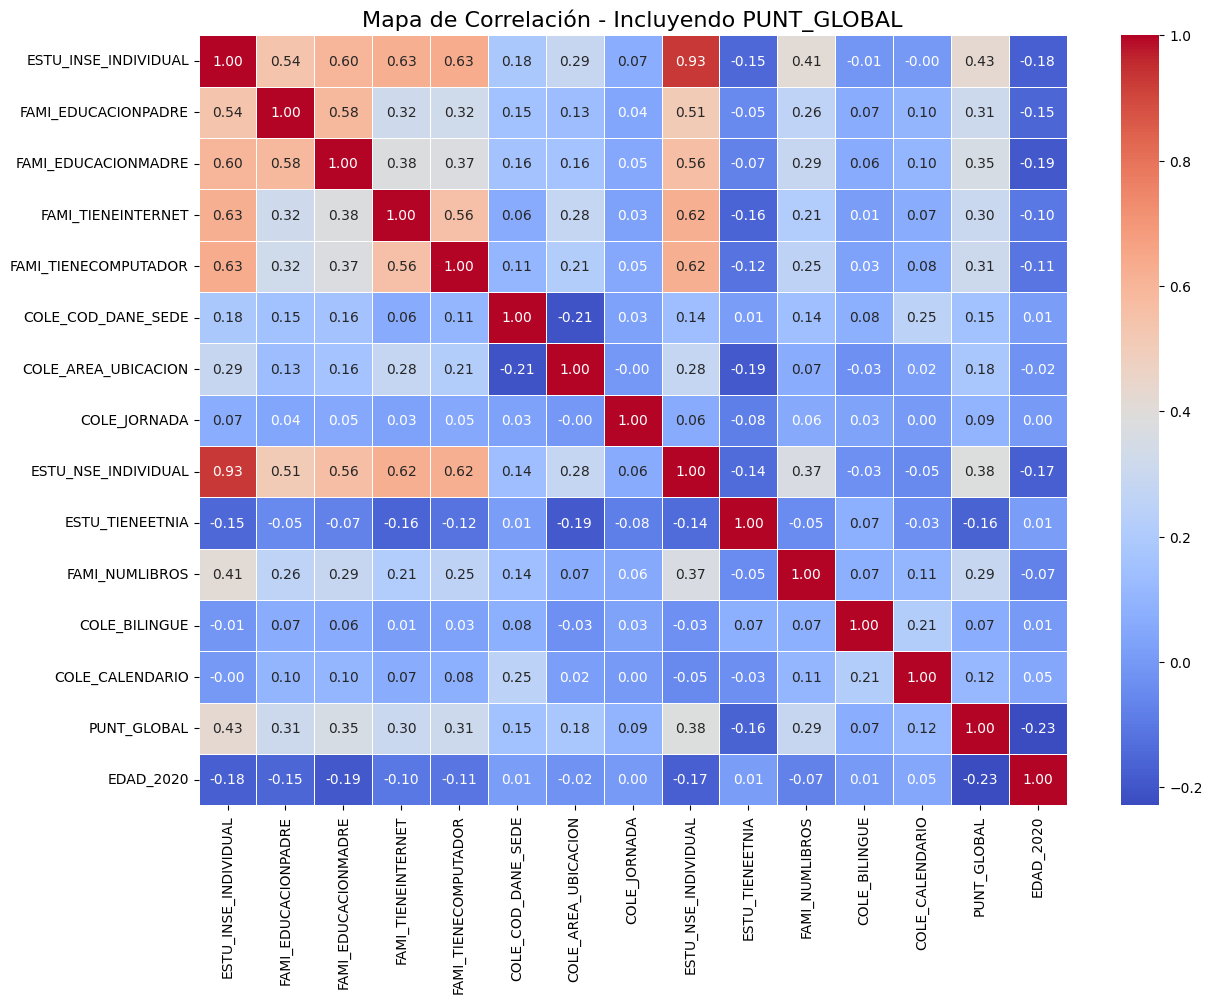

Correlaciones con PUNT_GLOBAL (ordenadas):
PUNT_GLOBAL             1.000000
ESTU_INSE_INDIVIDUAL    0.426511
ESTU_NSE_INDIVIDUAL     0.383789
FAMI_EDUCACIONMADRE     0.354604
FAMI_TIENECOMPUTADOR    0.312480
FAMI_EDUCACIONPADRE     0.310936
FAMI_TIENEINTERNET      0.303491
FAMI_NUMLIBROS          0.288631
COLE_AREA_UBICACION     0.181956
COLE_COD_DANE_SEDE      0.151416
COLE_CALENDARIO         0.115812
COLE_JORNADA            0.094985
COLE_BILINGUE           0.072464
ESTU_TIENEETNIA        -0.164514
EDAD_2020              -0.228957
Name: PUNT_GLOBAL, dtype: float64


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns


corr = df_encoded.corr(numeric_only=True)


plt.figure(figsize=(14,10))
sns.heatmap(
    corr, 
    cmap="coolwarm", 
    annot=True,      
    fmt=".2f",       
    linewidths=0.5, 
    cbar=True
)
plt.title("Mapa de Correlación - Incluyendo PUNT_GLOBAL", fontsize=16)
plt.show()


corr_target = corr["PUNT_GLOBAL"].sort_values(ascending=False)
print("Correlaciones con PUNT_GLOBAL (ordenadas):")
print(corr_target)


=== Estadísticas descriptivas ===
                            mean  mediana        std     varianza
ESTU_NSE_INDIVIDUAL     2.383923      2.0   0.827165     0.684202
ESTU_INSE_INDIVIDUAL   50.764184     50.0   9.176184    84.202344
FAMI_EDUCACIONMADRE     5.770042      6.0   2.695108     7.263608
FAMI_TIENECOMPUTADOR    0.588462      1.0   0.492113     0.242175
EDAD_2020              16.561986     16.0   2.493712     6.218601
FAMI_EDUCACIONPADRE     5.116648      5.0   2.846628     8.103292
ESTU_TIENEETNIA         0.061683      0.0   0.240579     0.057878
PUNT_GLOBAL           249.565962    246.0  49.568905  2457.076326


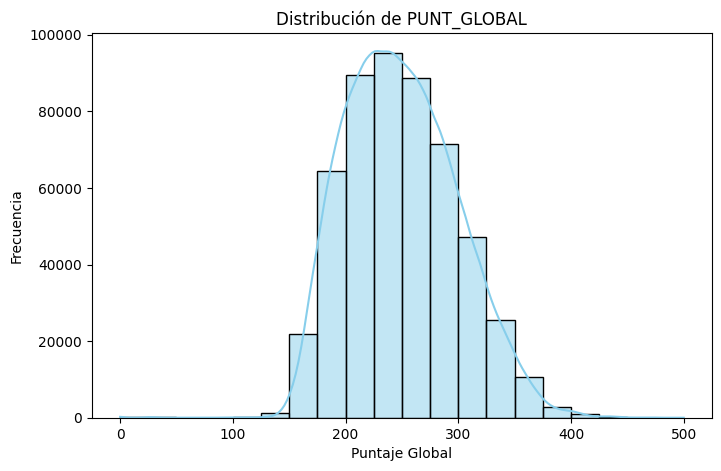

In [39]:

variables = [
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_INSE_INDIVIDUAL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENECOMPUTADOR",
    "EDAD_2020",
    "FAMI_EDUCACIONPADRE",
    "ESTU_TIENEETNIA"
]


stats = df_encoded[variables + ['PUNT_GLOBAL']].describe().T
stats['mediana'] = df_encoded[variables + ['PUNT_GLOBAL']].median()
stats['varianza'] = df_encoded[variables + ['PUNT_GLOBAL']].var()
print("=== Estadísticas descriptivas ===")
print(stats[['mean','mediana','std','varianza']])


plt.figure(figsize=(8,5))
sns.histplot(df_encoded['PUNT_GLOBAL'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de PUNT_GLOBAL')
plt.xlabel('Puntaje Global')
plt.ylabel('Frecuencia')
plt.show()



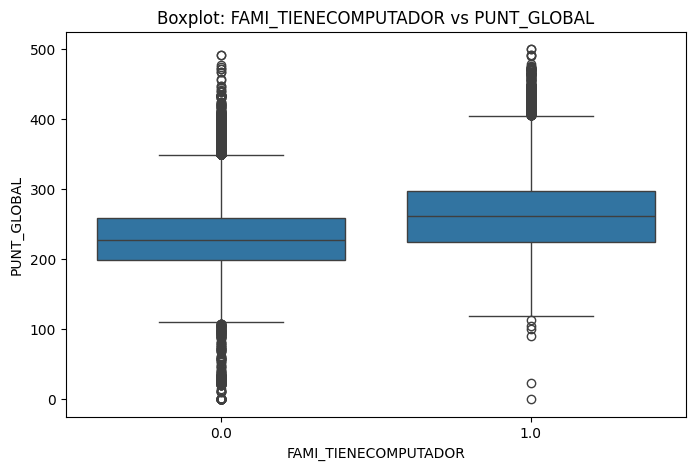

In [40]:
# 2.3 Boxplot categórica: FAMI_TIENECOMPUTADOR
plt.figure(figsize=(8,5))
sns.boxplot(x='FAMI_TIENECOMPUTADOR', y='PUNT_GLOBAL', data=df_encoded)
plt.title('Boxplot: FAMI_TIENECOMPUTADOR vs PUNT_GLOBAL')
plt.show()

/var/folders/09/7m8tm9612zg736zrjcvhm_000000gn/T/ipykernel_2564/608743797.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='ESTU_NSE_INDIVIDUAL', y='PUNT_GLOBAL', data=df_encoded, inner='quartile', palette='pastel')


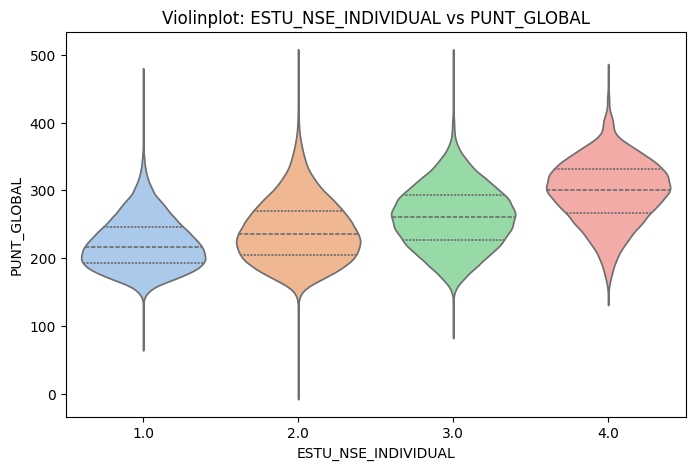

In [41]:
# 2.4 Violinplot continua: ESTU_NSE_INDIVIDUAL
plt.figure(figsize=(8,5))
sns.violinplot(x='ESTU_NSE_INDIVIDUAL', y='PUNT_GLOBAL', data=df_encoded, inner='quartile', palette='pastel')
plt.title('Violinplot: ESTU_NSE_INDIVIDUAL vs PUNT_GLOBAL')
plt.show()

/var/folders/09/7m8tm9612zg736zrjcvhm_000000gn/T/ipykernel_2564/6719749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='ESTU_TIENEETNIA', y='PUNT_GLOBAL', data=df_encoded, inner='quartile', palette='pastel')


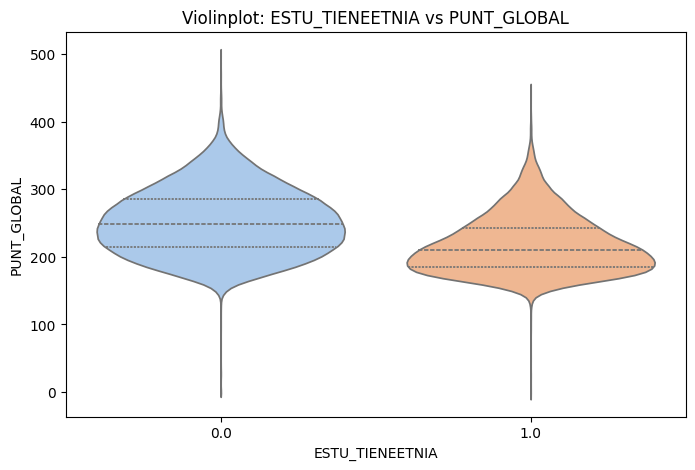

In [42]:
# 2.5 Violinplot categórica: ESTU_TIENEETNIA
plt.figure(figsize=(8,5))
sns.violinplot(x='ESTU_TIENEETNIA', y='PUNT_GLOBAL', data=df_encoded, inner='quartile', palette='pastel')
plt.title('Violinplot: ESTU_TIENEETNIA vs PUNT_GLOBAL')
plt.show()

## Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el *stakeholder*.

Pautas generales:

* Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
* Utilizar librerías especializadas (ej., `statsmodels`, `sklearn`, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
* Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
* Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.

Preguntas guía:

* ¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


features = [
   "ESTU_NSE_INDIVIDUAL",
    "ESTU_INSE_INDIVIDUAL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENECOMPUTADOR",
    "EDAD_2020",
    "FAMI_EDUCACIONPADRE",
    "ESTU_TIENEETNIA"
    
]

X = df_encoded[features]
y = df_encoded["PUNT_GLOBAL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)


y_pred = modelo.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Resultados del modelo de Regresión Lineal")
print("-----------------------------------------")
print(f"Coeficientes: {dict(zip(features, modelo.coef_))}")
print(f"Intercepto: {modelo.intercept_:.2f}")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


Resultados del modelo de Regresión Lineal
-----------------------------------------
Coeficientes: {'ESTU_NSE_INDIVIDUAL': -7.570748767517709, 'ESTU_INSE_INDIVIDUAL': 1.887520828123459, 'FAMI_EDUCACIONMADRE': 2.0465688273811518, 'FAMI_TIENECOMPUTADOR': 7.995999957607334, 'EDAD_2020': -2.919617759791297, 'FAMI_EDUCACIONPADRE': 1.1540449240389055, 'ESTU_TIENEETNIA': -22.066183222143973}
Intercepto: 199.06
R²: 0.2367
RMSE: 43.38


In [44]:


features = [
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_INSE_INDIVIDUAL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENECOMPUTADOR",
    "EDAD_2020",
    "FAMI_EDUCACIONPADRE",
    "ESTU_TIENEETNIA"
]

X = df_encoded[features]
y = df_encoded["PUNT_GLOBAL"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)


best_rf.fit(X_train, y_train)


y_pred = best_rf.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Resultados del Random Forest final")
print("----------------------------------")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")


importances = best_rf.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.4f}")


Resultados del Random Forest final
----------------------------------
R²: 0.2931
RMSE: 41.74
ESTU_NSE_INDIVIDUAL: 0.1634
ESTU_INSE_INDIVIDUAL: 0.2995
FAMI_EDUCACIONMADRE: 0.1780
FAMI_TIENECOMPUTADOR: 0.0560
EDAD_2020: 0.1756
FAMI_EDUCACIONPADRE: 0.0886
ESTU_TIENEETNIA: 0.0390


## Fase 4

Deberás elegir y realizar una de las dos alternativas que se encuentran a continuación.

### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

* Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
* Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
* Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
* Utilizar una librería especializada (ej., `ipywidgets`, `panel`, etc.) para implementar la herramienta.

Preguntas guía:

* ¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
* ¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?

In [ ]:
# Implementa tu respuesta en esta celda}
from ipywidgets import interact, Dropdown

# Lista de variables para explorar
variables = [
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_INSE_INDIVIDUAL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENECOMPUTADOR",
    "EDAD_2020",
    "FAMI_EDUCACIONPADRE",
    "ESTU_TIENEETNIA"
]


def explorar_variable(var):
    plt.figure(figsize=(8,5))
    sns.histplot(df_encoded['PUNT_GLOBAL'], bins=20, kde=True, color='skyblue')
    plt.title('Distribución de PUNT_GLOBAL')
    plt.xlabel('Puntaje Global')
    plt.ylabel('Frecuencia')
    plt.show()
    

    if df_encoded[var].nunique() > 10:
    
        df_encoded[f'{var}_bin'] = pd.qcut(df_encoded[var], q=5, duplicates='drop')
        plt.figure(figsize=(8,5))
        sns.boxplot(x=f'{var}_bin', y='PUNT_GLOBAL', data=df_encoded)
        plt.title(f'Boxplot: {var} (binned) vs PUNT_GLOBAL')
        plt.show()
        
        plt.figure(figsize=(8,5))
        sns.violinplot(x=f'{var}_bin', y='PUNT_GLOBAL', data=df_encoded, inner='quartile', palette='pastel')
        plt.title(f'Violinplot: {var} (binned) vs PUNT_GLOBAL')
        plt.show()
    else:

        plt.figure(figsize=(8,5))
        sns.boxplot(x=var, y='PUNT_GLOBAL', data=df_encoded)
        plt.title(f'Boxplot: {var} vs PUNT_GLOBAL')
        plt.show()
        
        plt.figure(figsize=(8,5))
        sns.violinplot(x=var, y='PUNT_GLOBAL', data=df_encoded, inner='quartile', palette='pastel')
        plt.title(f'Violinplot: {var} vs PUNT_GLOBAL')
        plt.show()

interact(explorar_variable, var=Dropdown(options=variables, description='Variable:'));


interactive(children=(Dropdown(description='Variable:', options=('ESTU_NSE_INDIVIDUAL', 'ESTU_INSE_INDIVIDUAL'…

In [47]:


# Lista de features
features = [
    "ESTU_NSE_INDIVIDUAL",
    "ESTU_INSE_INDIVIDUAL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_TIENECOMPUTADOR",
    "EDAD_2020",
    "FAMI_EDUCACIONPADRE",
    "ESTU_TIENEETNIA"
]

# Diccionario para almacenar los valores del usuario
user_input = {}

print("Por favor, ingresa los siguientes datos:")

for f in features:
    while True:
        try:
            val = input(f"{f}: ")
            # Convertir a float
            val = float(val)
            user_input[f] = [val]  # el modelo espera un DataFrame, por eso usamos lista
            break
        except ValueError:
            print("Error: ingresa un número válido.")

# Crear DataFrame
df_user = pd.DataFrame(user_input)

# Predecir con el modelo Random Forest entrenado
predicted_score = best_rf.predict(df_user)[0]

print(f"\nTu puntaje global estimado es: {predicted_score:.2f}")


Por favor, ingresa los siguientes datos:

Tu puntaje global estimado es: 236.24


### Alternativa 2: registrar en bases de datos relacionales con PySpark

En esta fase desarrollarás, a partir de alguno de los análisis realizados, un _script_ que sea relevante en el contexto del problema, acompañado de las instrucciones necesarias para que un usuario lo pueda ejecutar.

Pautas generales:

* Cargar en una base de datos relacional (tipo SQL) el segmento de los datos sobre el cual profundizaste en tu anális, utilizando una tabla distinta para cada categoría de campos. Por ejemplo, una categoría puedes ser información del colegio; en cuyo caso, una tabla debería contener un registro único para cada colegio y todos los campos asociados.

* Los campos, a excepción de los identificadores, deben existir en un única tabla.

* Cada registro debe existir una única vez en su respectiva tabla.

* Cada registro debe tener un identificador único en su tabla, el cual establece una relación entre tablas.

* Seleccionar uno de los modelos predictivos implementados.

* Crear en la base de datos relacional una tabla que contenga únicamente los identificadores del registro y la predicción de la variable de respuesta hecha por el modelo.

* Desarrollar _queries_ de SQL según las siguientes indicaciones y concluir acerca de los resultados:
    * Un _query_ que seleccione todos registros y los agregue en una única tabla. Para esto debes relacionar las tablas por su identificador, utilizando el método `JOIN`.
    * Un _query_ que contenga el puntaje promedio de los estudiantes, agrupado por año y por colegio.
    * Distintos _queries_ que calculen medidas de error de predicción del modelo a partir de los datos reales y las predicciones respectivas. Debes reportar el error para cada registro, el error total de los registros de entrenamiento y el error total de los registros de prueba.
    * Haz dos _queries_ adicionales que resulten interesantes.

Preguntas guía:

* ¿Cómo aporta la segmentación de los datos en categorías de campos al manejo de los datos?
* ¿Qué filtros y agrupaciones podemos aplicar sobre los datos con el fin de obtener información relevante?

In [46]:
# Implementa tu respuesta en esta celda


## Referencias

*  J. VanderPlas (2016) *Python Data Science Handbook: Essential Tools for Working with Data* O'Reilly Media, Inc.
*  scikit-learn developers . (2020). Demo of DBSCAN clustering algorithm. 11 Diciembre 2020, de scikit-learn <br> https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py

## Créditos

__Autores__: Camilo Hernando Gómez Castro, Alejandro Mantilla Redondo, Jose Fernando Barrera de Plaza, Diego Alejandro Cely Gómez.

__Fecha última actualización__: 29/09/2022